In [ ]:
# ## VERİ SETİ İNCELEME : 
# Case Type: Davanın türü (Criminal, Civil, Commercial)  
# Case Duration (Days): Davanın süresi (gün olarak)  
# Judge Experience (Years): Hakimin deneyim yılı  
# Number of Witnesses: Tanık sayısı  
# Legal Fees (USD): Hukuk masrafları (USD olarak)  
# Plaintiff's Reputation: Davacının itibarı (1: Düşük, 2: Orta, 3: Yüksek)  
# Defendant's Wealth (USD): Davalının serveti  
# Number of Evidence Items: Delil sayısı  
# Number of Legal Precedents: İlgili hukuki emsal sayısı  
# Settlement Offered (USD): Teklif edilen uzlaşma miktarı  
# Severity: Davanın ciddiyet derecesi (1: Düşük, 2: Orta, 3: Yüksek)  
# Outcome: Davanın sonucu (0: Kaybetmek, 1: Kazanmak) 

In [124]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.tree import plot_tree

In [126]:
data = pd.read_csv('dava_sonuclari.csv')
data.head()

,Case Type,Case Duration (Days),Judge Experience (Years),Number of Witnesses,Legal Fees (USD),Plaintiff's Reputation,Defendant's Wealth (USD),Number of Evidence Items,Number of Legal Precedents,Settlement Offered (USD),Severity,Outcome
0,Criminal,221,39,18,24306,2,663160,3,1,29014,1,0
1,Civil,212,14,1,42444,3,252011,67,4,21591,1,0
2,Civil,47,6,19,21418,1,307309,66,6,25530,3,0
3,Commercial,358,13,9,45005,3,285111,63,1,28470,1,0
4,Criminal,33,17,17,36315,2,84229,38,2,38244,2,0


In [128]:
# ### Veri Ön İşleme:
# * Veri setini inceleyin ve eksik veya aykırı değerler olup olmadığını kontrol edin.  
# * Gerektiğinde eksik verileri doldurun veya çıkarın.  
# * Özelliklerin ölçeklendirilmesi gibi gerekli veri dönüşümlerini uygulayın. 

In [130]:
print("Eksik Değerler:\n",data.isnull().sum())

Eksik Değerler:
 Case Type                     0
Case Duration (Days)          0
Judge Experience (Years)      0
Number of Witnesses           0
Legal Fees (USD)              0
Plaintiff's Reputation        0
Defendant's Wealth (USD)      0
Number of Evidence Items      0
Number of Legal Precedents    0
Settlement Offered (USD)      0
Severity                      0
Outcome                       0
dtype: int64


In [132]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Case Type                   200 non-null    object
 1   Case Duration (Days)        200 non-null    int64 
 2   Judge Experience (Years)    200 non-null    int64 
 3   Number of Witnesses         200 non-null    int64 
 4   Legal Fees (USD)            200 non-null    int64 
 5   Plaintiff's Reputation      200 non-null    int64 
 6   Defendant's Wealth (USD)    200 non-null    int64 
 7   Number of Evidence Items    200 non-null    int64 
 8   Number of Legal Precedents  200 non-null    int64 
 9   Settlement Offered (USD)    200 non-null    int64 
 10  Severity                    200 non-null    int64 
 11  Outcome                     200 non-null    int64 
dtypes: int64(11), object(1)
memory usage: 18.9+ KB


In [134]:
# ### Veri Setini Ayırma:
# * Veri setini eğitim ve test setleri olarak ayırın (örn. %80 eğitim, %20 test).

In [136]:

X = data.drop("Outcome",axis=1)
y = data["Outcome"]

X = pd.get_dummies(X, columns=['Case Type'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print("Eğitim veri sayısı:", X_train.shape[0])
print("Test veri sayısı:", X_test.shape[0])

Eğitim veri sayısı: 160
Test veri sayısı: 40


In [138]:
# ### Model Kurulumu:
# * Karar ağacı modelini oluşturun ve eğitim verileri üzerinde eğitin.

In [144]:
model = DecisionTreeClassifier(random_state=0, max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [146]:
# ### Modeli Değerlendirme:
# * Test verilerini kullanarak modelin doğruluğunu değerlendirin.
# * Doğruluk, precision, recall ve F1-score gibi performans metriklerini hesaplayın.

In [148]:
print("Doğruluk:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

Doğruluk: 1.0
Precision: 0.0
Recall: 0.0
F1-Score: 0.0

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



C:\Users\MONSTER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\MONSTER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\MONSTER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [116]:
# ### Sonuçları Görselleştirme:
# * Karar ağacının yapısını görselleştirin.
# * Karar ağacının nasıl çalıştığını ve hangi özelliklerin davanın sonucunu belirlemede en etkili olduğunu açıklayın.

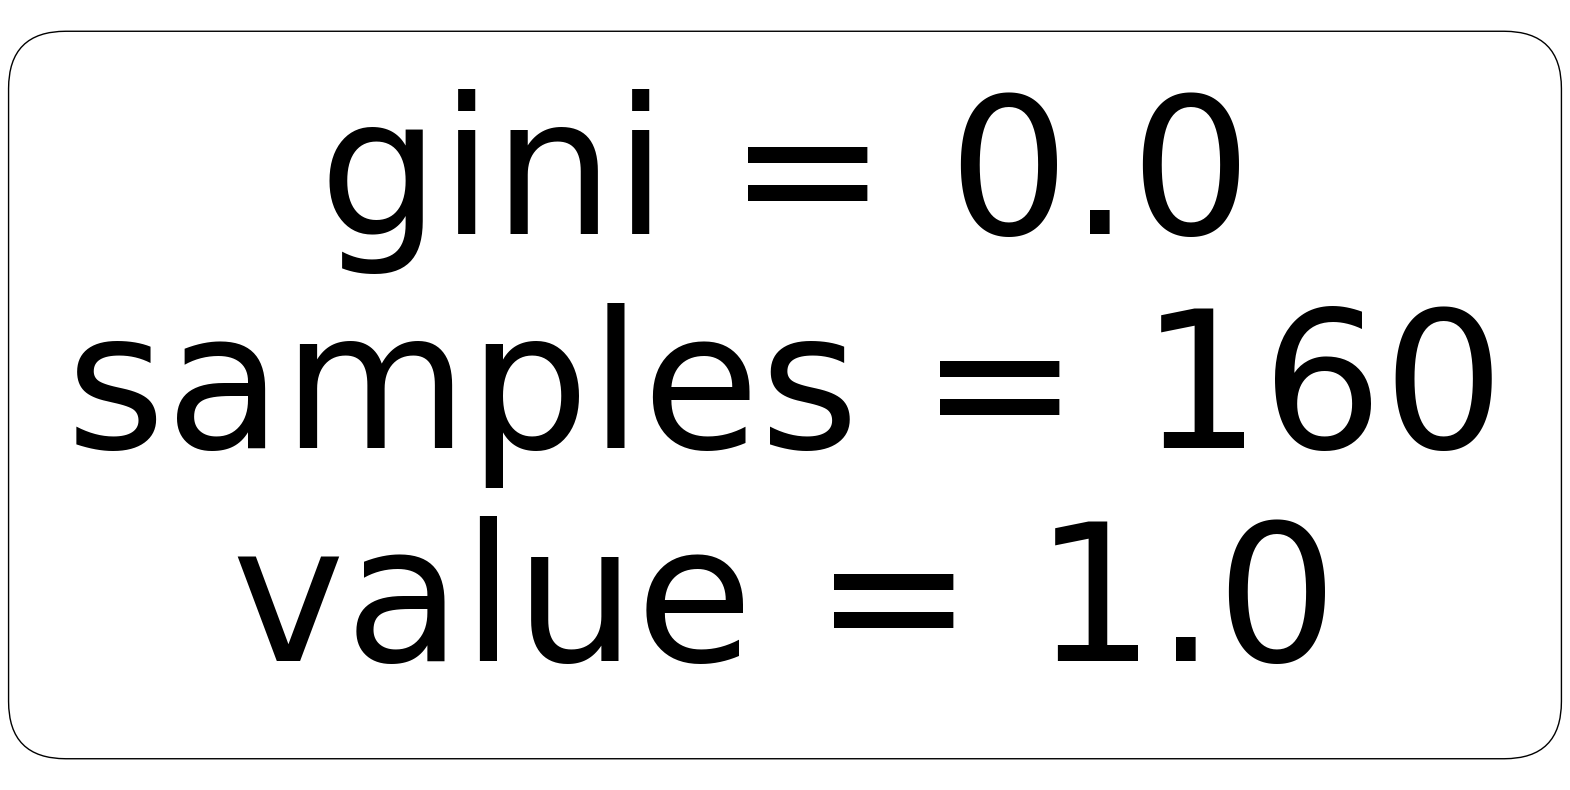

In [150]:
plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=X.columns, 
          class_names=['Kaybetti', 'Kazandı'], rounded=True)
plt.show()

In [ ]:
# Modelin en önemli bulgusu, bir davanın Kazanılıp Kaybedileceğini belirlemede Hukuki Ücretler ve Dava Süresi gibi faktörlerin aksine, 
# Teklif Edilen Uzlaşma Miktarı ve Hakim Deneyimi gibi etkenlerin en belirleyici rolü oynadığıdır.